In [101]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

In [102]:
X_train = np.load("../dataset/X_train.npy")
y_train = np.load("../dataset/y_train.npy")

X_val = np.load("../dataset/X_val.npy")
y_val = np.load("../dataset/y_val.npy")

X_test = np.load("../dataset/X_test.npy")
y_test = np.load("../dataset/y_test.npy")

In [103]:
# Convert to tensor
X_train = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_val = torch.tensor(X_val, dtype=torch.float32).permute(0, 3, 1, 2)
X_test = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [104]:
class BottleCNN(nn.Module):
    def __init__(self):
        super(BottleCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [105]:
model = BottleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [106]:
epochs = 10

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
        val_losses.append(val_loss.item())

    print(f"Epoch {epoch+1}, Train Loss: {loss.item()}, Val Loss: {val_loss.item()}")

Epoch 1, Train Loss: 0.6916847229003906, Val Loss: 0.651577353477478
Epoch 2, Train Loss: 0.6973196268081665, Val Loss: 1.1015311479568481
Epoch 3, Train Loss: 1.0822385549545288, Val Loss: 0.5945361852645874
Epoch 4, Train Loss: 0.6165136098861694, Val Loss: 0.6976365447044373
Epoch 5, Train Loss: 0.6968672275543213, Val Loss: 0.5494266748428345
Epoch 6, Train Loss: 0.550482451915741, Val Loss: 0.5017050504684448
Epoch 7, Train Loss: 0.5079559683799744, Val Loss: 0.46992605924606323
Epoch 8, Train Loss: 0.47326070070266724, Val Loss: 0.39540794491767883
Epoch 9, Train Loss: 0.37938326597213745, Val Loss: 0.3202667534351349
Epoch 10, Train Loss: 0.32391080260276794, Val Loss: 0.25439199805259705


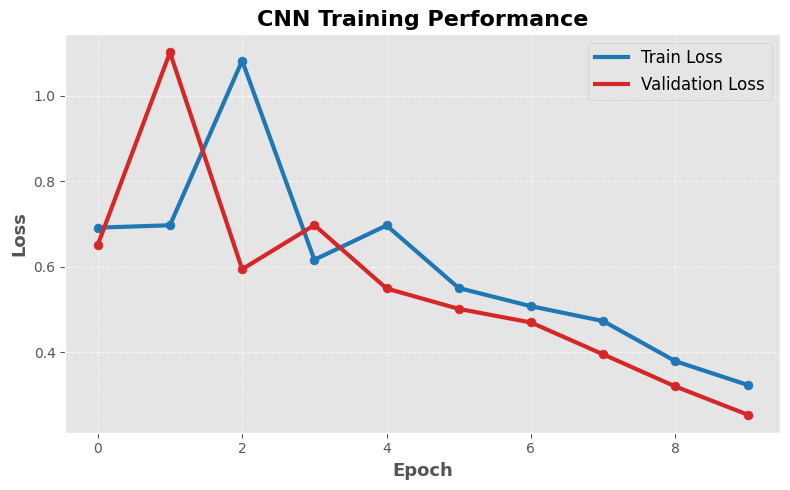

In [109]:
plt.figure(figsize=(8,5))

# Lines with custom colors
plt.plot(train_losses, label="Train Loss", linewidth=3, color="#1f77b4")   # blue
plt.plot(val_losses, label="Validation Loss", linewidth=3, color="#d62728")  # red

# Scatter points with matching colors
plt.scatter(range(len(train_losses)), train_losses, color="#1f77b4", s=40)
plt.scatter(range(len(val_losses)), val_losses, color="#d62728", s=40)

# Labels and title with better fonts
plt.xlabel("Epoch", fontsize=13, fontweight='bold')
plt.ylabel("Loss", fontsize=13, fontweight='bold')
plt.title("CNN Training Performance", fontsize=16, fontweight='bold')

# Legend styling
plt.legend(fontsize=12)

# Grid styling
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [110]:
model.eval()
with torch.no_grad():
    outputs = model(X_test)
    _, preds = torch.max(outputs, 1)

    accuracy = (preds == y_test).float().mean()

print("CNN Test Accuracy:", accuracy.item())

CNN Test Accuracy: 0.9268292784690857


In [127]:
import os

os.makedirs("../models", exist_ok=True)

torch.save(model.state_dict(), "../models/cnn_model.pth")

print("Model saved successfully!")

Model saved successfully!


## Activation Function Comparison

In [111]:
class BottleCNN_Exp(nn.Module):
    def __init__(self, activation='relu'):
        super(BottleCNN_Exp, self).__init__()

        if activation == 'relu':
            act = nn.ReLU()
        elif activation == 'sigmoid':
            act = nn.Sigmoid()
        elif activation == 'tanh':
            act = nn.Tanh()
        elif activation == 'leakyrelu':
            act = nn.LeakyReLU(0.1)
        else:
            raise ValueError("Unsupported activation")

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            act,
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            act,
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            act,
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            act,
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [112]:
def train_model_batch_acc(model, optimizer, epochs=10):
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        total_loss = 0

        for X_batch, y_batch in train_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        train_losses.append(total_loss / len(train_loader))
        train_accs.append(correct / total)

        # Validation
        model.eval()
        correct, total = 0, 0
        val_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accs.append(correct / total)

        print(f"Epoch {epoch+1}: Train Acc={train_accs[-1]:.3f}, Val Acc={val_accs[-1]:.3f}")

    return train_losses, val_losses, train_accs, val_accs

In [113]:
from torch.utils.data import TensorDataset, DataLoader

# Create datasets
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

# Create loaders (mini-batch training)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [114]:
activations = ['relu', 'sigmoid', 'tanh', 'leakyrelu']
results = {}

for act in activations:
    print(f"\nTraining with {act.upper()}")

    model = BottleCNN_Exp(activation=act)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_loss, val_loss, train_acc, val_acc = train_model_batch_acc(model, optimizer)

    results[act] = {
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc
    }


Training with RELU
Epoch 1: Train Acc=0.492, Val Acc=0.500
Epoch 2: Train Acc=0.598, Val Acc=0.950
Epoch 3: Train Acc=0.852, Val Acc=0.900
Epoch 4: Train Acc=0.889, Val Acc=1.000
Epoch 5: Train Acc=0.931, Val Acc=1.000
Epoch 6: Train Acc=0.974, Val Acc=0.950
Epoch 7: Train Acc=0.984, Val Acc=1.000
Epoch 8: Train Acc=0.989, Val Acc=1.000
Epoch 9: Train Acc=0.995, Val Acc=1.000
Epoch 10: Train Acc=0.989, Val Acc=1.000

Training with SIGMOID
Epoch 1: Train Acc=0.497, Val Acc=0.500
Epoch 2: Train Acc=0.513, Val Acc=0.500
Epoch 3: Train Acc=0.519, Val Acc=0.500
Epoch 4: Train Acc=0.497, Val Acc=0.500
Epoch 5: Train Acc=0.487, Val Acc=0.500
Epoch 6: Train Acc=0.503, Val Acc=0.500
Epoch 7: Train Acc=0.519, Val Acc=0.500
Epoch 8: Train Acc=0.545, Val Acc=0.500
Epoch 9: Train Acc=0.614, Val Acc=0.500
Epoch 10: Train Acc=0.571, Val Acc=0.500

Training with TANH
Epoch 1: Train Acc=0.630, Val Acc=0.975
Epoch 2: Train Acc=0.735, Val Acc=0.875
Epoch 3: Train Acc=0.942, Val Acc=0.975
Epoch 4: Train 

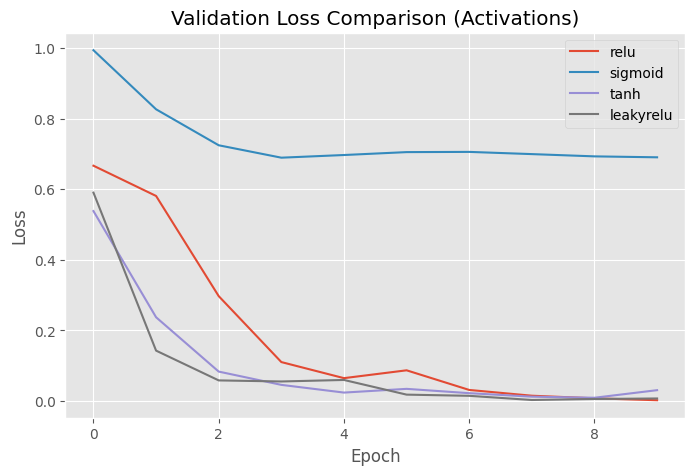

In [115]:
plt.figure(figsize=(8,5))

for act in activations:
    plt.plot(results[act]["val_loss"], label=f"{act}")

plt.title("Validation Loss Comparison (Activations)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

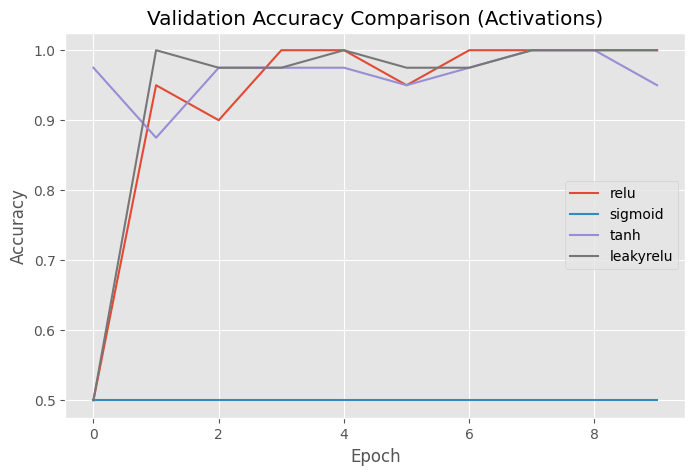

In [116]:
plt.figure(figsize=(8,5))

for act in activations:
    plt.plot(results[act]["val_acc"], label=f"{act}")

plt.title("Validation Accuracy Comparison (Activations)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [117]:
best_model = BottleCNN_Exp(activation='relu')
optimizer = torch.optim.Adam(best_model.parameters(), lr=0.001)

train_model_batch_acc(best_model, optimizer)

Epoch 1: Train Acc=0.492, Val Acc=0.500
Epoch 2: Train Acc=0.661, Val Acc=0.850
Epoch 3: Train Acc=0.847, Val Acc=0.875
Epoch 4: Train Acc=0.899, Val Acc=0.925
Epoch 5: Train Acc=0.910, Val Acc=1.000
Epoch 6: Train Acc=0.942, Val Acc=1.000
Epoch 7: Train Acc=0.995, Val Acc=1.000
Epoch 8: Train Acc=0.995, Val Acc=1.000
Epoch 9: Train Acc=0.995, Val Acc=1.000
Epoch 10: Train Acc=0.984, Val Acc=0.975


([0.8169201215108236,
  0.615798552831014,
  0.413283035159111,
  0.25093504041433334,
  0.20116141438484192,
  0.13784357905387878,
  0.0412952546030283,
  0.0259088051194946,
  0.029365466015102964,
  0.0264600549514095],
 [0.6585975587368011,
  0.5441262722015381,
  0.27734848856925964,
  0.18230709433555603,
  0.06412362866103649,
  0.040808603167533875,
  0.009983423165977001,
  0.007904554018750787,
  0.031551833264529705,
  0.01893427560571581],
 [0.49206349206349204,
  0.6613756613756614,
  0.8465608465608465,
  0.8994708994708994,
  0.91005291005291,
  0.9417989417989417,
  0.9947089947089947,
  0.9947089947089947,
  0.9947089947089947,
  0.9841269841269841],
 [0.5, 0.85, 0.875, 0.925, 1.0, 1.0, 1.0, 1.0, 1.0, 0.975])

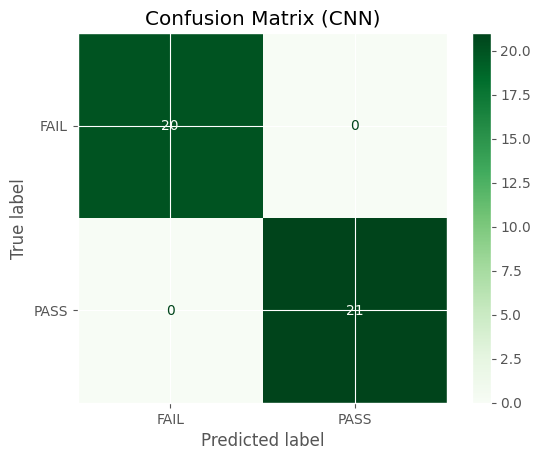

In [124]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model.eval()
with torch.no_grad():
    outputs = best_model(X_test)
    _, preds = torch.max(outputs, 1)

cm = confusion_matrix(y_test.numpy(), preds.numpy())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["FAIL", "PASS"])
disp.plot(cmap='Greens')
plt.title("Confusion Matrix (CNN)")
plt.show()

In [125]:
weak_model = BottleCNN_Exp(activation='sigmoid')
optimizer = torch.optim.Adam(weak_model.parameters(), lr=0.001)

train_model_batch_acc(weak_model, optimizer)

Epoch 1: Train Acc=0.487, Val Acc=0.500
Epoch 2: Train Acc=0.513, Val Acc=0.500
Epoch 3: Train Acc=0.513, Val Acc=0.500
Epoch 4: Train Acc=0.513, Val Acc=0.500
Epoch 5: Train Acc=0.503, Val Acc=0.500
Epoch 6: Train Acc=0.481, Val Acc=0.500
Epoch 7: Train Acc=0.481, Val Acc=0.500
Epoch 8: Train Acc=0.492, Val Acc=0.500
Epoch 9: Train Acc=0.492, Val Acc=0.500
Epoch 10: Train Acc=0.529, Val Acc=0.500


([1.5454171200593312,
  1.4168973763783772,
  1.1282112896442413,
  0.889674057563146,
  0.7813662985960642,
  0.7203166286150614,
  0.7252989908059438,
  0.7128580510616302,
  0.7225444316864014,
  0.7110340694586436],
 [1.4069445729255676,
  1.1480304598808289,
  0.9256410002708435,
  0.773085206747055,
  0.6988277733325958,
  0.6902798712253571,
  0.7054155468940735,
  0.7137154042720795,
  0.7091444432735443,
  0.7004024684429169],
 [0.48677248677248675,
  0.5132275132275133,
  0.5132275132275133,
  0.5132275132275133,
  0.5026455026455027,
  0.48148148148148145,
  0.48148148148148145,
  0.49206349206349204,
  0.49206349206349204,
  0.5291005291005291],
 [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])

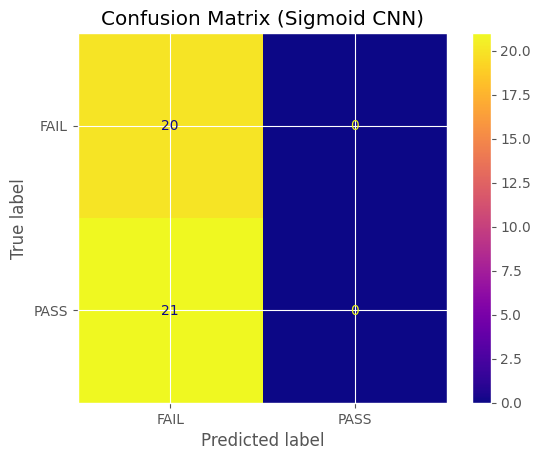

In [126]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

weak_model.eval()
with torch.no_grad():
    outputs = weak_model(X_test)
    _, preds = torch.max(outputs, 1)

cm = confusion_matrix(y_test.numpy(), preds.numpy())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["FAIL", "PASS"])
disp.plot(cmap='plasma')
plt.title("Confusion Matrix (Sigmoid CNN)")
plt.show()